<a href="https://colab.research.google.com/github/Krishishah7/ai-learning-series/blob/main/03_computer_vision/05_data_augmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Augmentation

Data Augmentation is a technique used to artificially increase the size and diversity of a training dataset by applying random transformations to existing images.

Instead of collecting more images, we create modified versions of the available images. These transformations preserve the original class label while introducing variations that help the model become more robust.

Common augmentation techniques include flipping, rotating, zooming, translating, and adjusting image brightness or contrast.

Data augmentation helps reduce overfitting, improves generalization, and is widely used in modern computer vision applications.

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1985s 12us/step


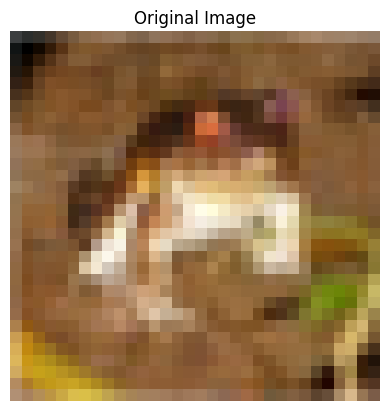

In [2]:
(X_train, y_train), _ = tf.keras.datasets.cifar10.load_data()

image = X_train[0]

plt.imshow(image)
plt.title("Original Image")
plt.axis("off")
plt.show()

In [3]:
data_augmentation = tf.keras.Sequential([

    tf.keras.layers.RandomFlip("horizontal"),

    tf.keras.layers.RandomRotation(0.2),

    tf.keras.layers.RandomZoom(0.2),

    tf.keras.layers.RandomTranslation(0.1, 0.1),

    tf.keras.layers.RandomContrast(0.2)

])

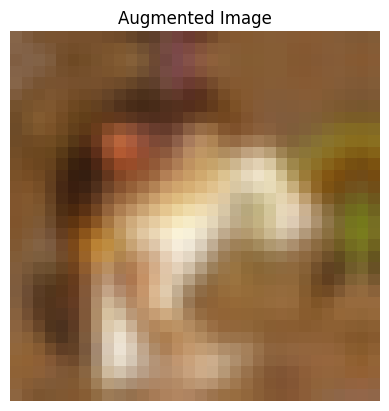

In [4]:
augmented_image = data_augmentation(image[None, ...], training=True)

plt.imshow(augmented_image[0].numpy().astype("uint8"))
plt.title("Augmented Image")
plt.axis("off")
plt.show()

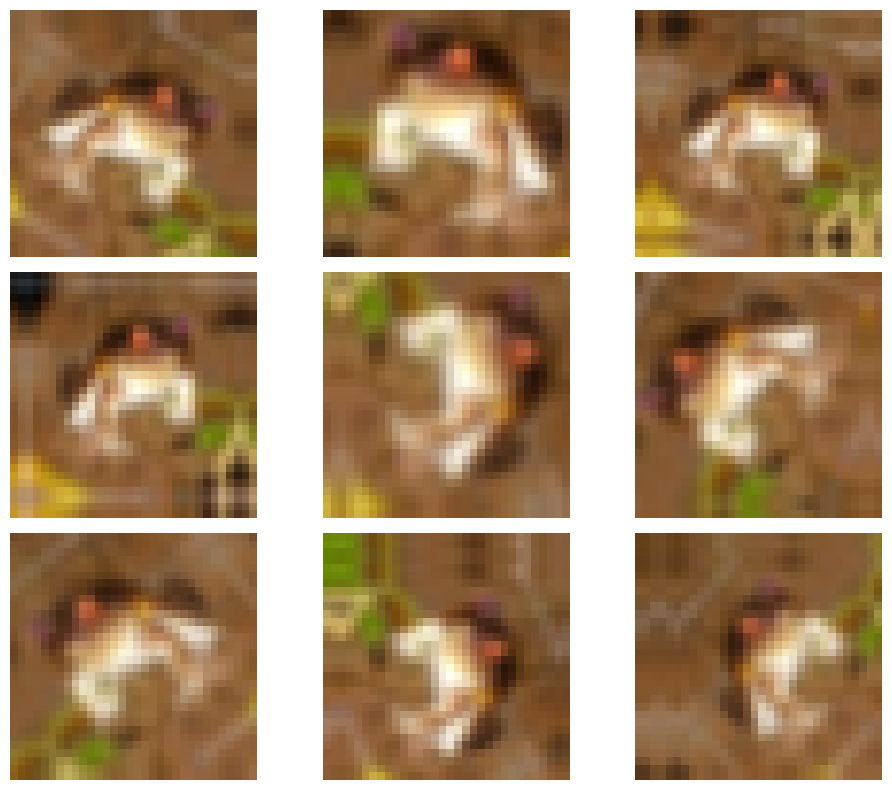

In [5]:
plt.figure(figsize=(10,8))

for i in range(9):

    augmented = data_augmentation(image[None,...], training=True)

    plt.subplot(3,3,i+1)

    plt.imshow(augmented[0].numpy().astype("uint8"))

    plt.axis("off")

plt.tight_layout()

plt.show()

In [6]:
import pandas as pd

comparison = pd.DataFrame({

    "Original Dataset":[
        "Limited images",
        "Higher overfitting risk",
        "Less variation"
    ],

    "With Augmentation":[
        "More diverse images",
        "Reduced overfitting",
        "Better generalization"
    ]

})

comparison

,Original Dataset,With Augmentation
0,Limited images,More diverse images
1,Higher overfitting risk,Reduced overfitting
2,Less variation,Better generalization


In [7]:
model = tf.keras.Sequential([

    data_augmentation,

    tf.keras.layers.Rescaling(1./255),

    tf.keras.layers.Conv2D(32,(3,3),activation="relu"),

    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(64,activation="relu"),

    tf.keras.layers.Dense(10,activation="softmax")

])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (1, 32, 32, 3)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (1, 32, 32, 3)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (1, 30, 30, 32)        │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (1, 15, 15, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (1, 7200)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (1, 64)                │       460,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (1, 10)                │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 462,410 (1.76 MB)

 Trainable params: 462,410 (1.76 MB)

 Non-trainable params: 0 (0.00 B)

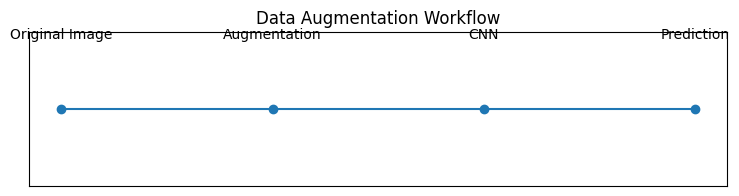

In [8]:
steps = [

    "Original Image",

    "Augmentation",

    "CNN",

    "Prediction"

]

plt.figure(figsize=(9,2))

plt.plot(range(len(steps)), [1]*len(steps), marker="o")

for i, step in enumerate(steps):
    plt.text(i,1.05,step,ha="center")

plt.xticks([])
plt.yticks([])

plt.title("Data Augmentation Workflow")

plt.show()